<a href="https://colab.research.google.com/github/Ratish-bit/AI-Assisted-Threat-Detection-dashboard/blob/main/notebooks/Python_Threat_Detection_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python Task – AI-Assisted Threat Detection Dashboard

## Cybersecurity Threat Events – Python Analysis & ML Modelling

**Project:** AI-Assisted Threat Detection Dashboard  
**Task:** Generate a synthetic cybersecurity threat events dataset, perform EDA using Pandas, detect anomalies with Isolation Forest, classify threats using Random Forest, compute composite risk scores, and evaluate model performance.  

**Tools Used:** Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn

---

## Tasks Overview

| Task | Description | Python Concepts |
|------|-------------|----------------|
| Task 1 | Setup & Data Generation | NumPy, Pandas, random |
| Task 2 | Exploratory Data Analysis | Pandas, Matplotlib, Seaborn |
| Task 3 | Anomaly Detection | Isolation Forest (sklearn) |
| Task 4 | Threat Classification | Random Forest (sklearn) |
| Task 5 | Risk Scoring | Pandas, NumPy |
| Task 6 | Model Evaluation | sklearn metrics |

In [1]:
# ============================================================
# TASK 1: Setup & Data Generation
# ============================================================
# Install / import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score,
                              recall_score, f1_score)
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Libraries imported successfully.")

# --- Generate synthetic cybersecurity threat events dataset ---
N = 1000  # number of events

protocols    = ['TCP', 'UDP', 'HTTP', 'HTTPS', 'SSH', 'DNS']
threat_types = ['BruteForce', 'DataExfiltration', 'MalwareBeacon',
                'PortScan', 'DDoS', 'Normal']

df = pd.DataFrame({
    'event_id'         : np.arange(1, N + 1),
    'timestamp'        : pd.date_range('2026-01-01', periods=N, freq='30min'),
    'source_ip'        : ['192.168.' + str(np.random.randint(1,10)) + '.' +
                           str(np.random.randint(1,255)) for _ in range(N)],
    'destination_ip'   : ['10.0.'    + str(np.random.randint(0,5))  + '.' +
                           str(np.random.randint(1,50))  for _ in range(N)],
    'protocol'         : np.random.choice(protocols, N,
                             p=[0.25,0.20,0.15,0.15,0.10,0.15]),
    'bytes_sent'       : np.random.exponential(scale=5000, size=N).astype(int),
    'bytes_received'   : np.random.exponential(scale=3000, size=N).astype(int),
    'duration_sec'     : np.round(np.random.exponential(scale=30, size=N), 2),
    'packet_count'     : np.random.randint(1, 500, N),
    'failed_logins'    : np.random.choice([0,1,2,3,4,5], N,
                             p=[0.60,0.20,0.10,0.05,0.03,0.02]),
    'label'            : np.random.choice(threat_types, N,
                             p=[0.10,0.10,0.10,0.10,0.10,0.50]),
    'asset_criticality': np.random.randint(1, 6, N),
    'vulnerability_score': np.round(np.random.uniform(0, 10, N), 1),
})

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

Libraries imported successfully.
Dataset shape: (1000, 13)

First 5 rows:


,event_id,timestamp,source_ip,destination_ip,protocol,bytes_sent,bytes_received,duration_sec,packet_count,failed_logins,label,asset_criticality,vulnerability_score
0,1,2026-01-01 00:00:00,192.168.7.180,10.0.3.1,UDP,2427,508,16.97,8,1,DataExfiltration,1,4.2
1,2,2026-01-01 00:30:00,192.168.8.189,10.0.0.20,UDP,3072,2375,47.75,330,0,DDoS,1,2.3
2,3,2026-01-01 01:00:00,192.168.5.103,10.0.3.43,DNS,1806,274,27.15,46,0,Normal,3,2.3
3,4,2026-01-01 01:30:00,192.168.3.215,10.0.4.47,DNS,13482,1421,65.30,325,0,Normal,2,9.0
4,5,2026-01-01 02:00:00,192.168.8.117,10.0.4.12,TCP,631,1600,15.88,114,0,Normal,3,8.3


TASK 2: Exploratory Data Analysis

--- Dataset Info ---
event_id                        int64
timestamp              datetime64[ns]
source_ip                      object
destination_ip                 object
protocol                       object
bytes_sent                      int64
bytes_received                  int64
duration_sec                  float64
packet_count                    int64
failed_logins                   int64
label                          object
asset_criticality               int64
vulnerability_score           float64
dtype: object

--- Null Values ---
event_id               0
timestamp              0
source_ip              0
destination_ip         0
protocol               0
bytes_sent             0
bytes_received         0
duration_sec           0
packet_count           0
failed_logins          0
label                  0
asset_criticality      0
vulnerability_score    0
dtype: int64

--- Summary Statistics ---
       bytes_sent  bytes_received  duration_sec  

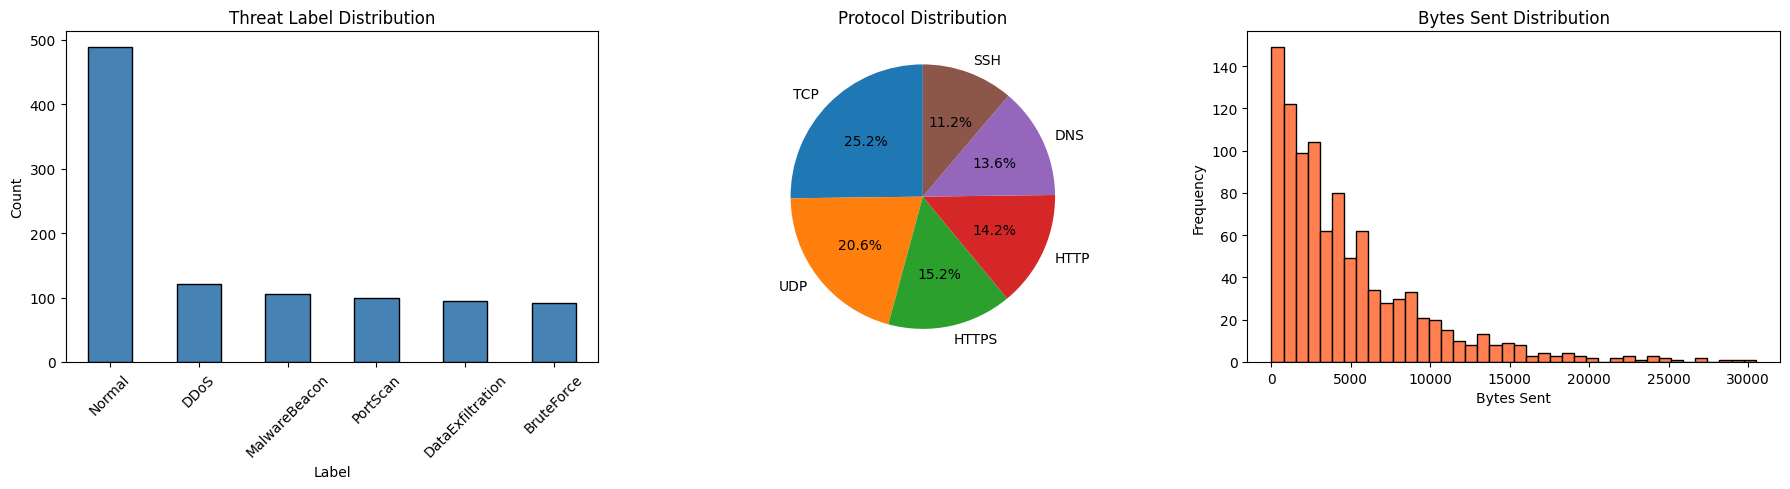

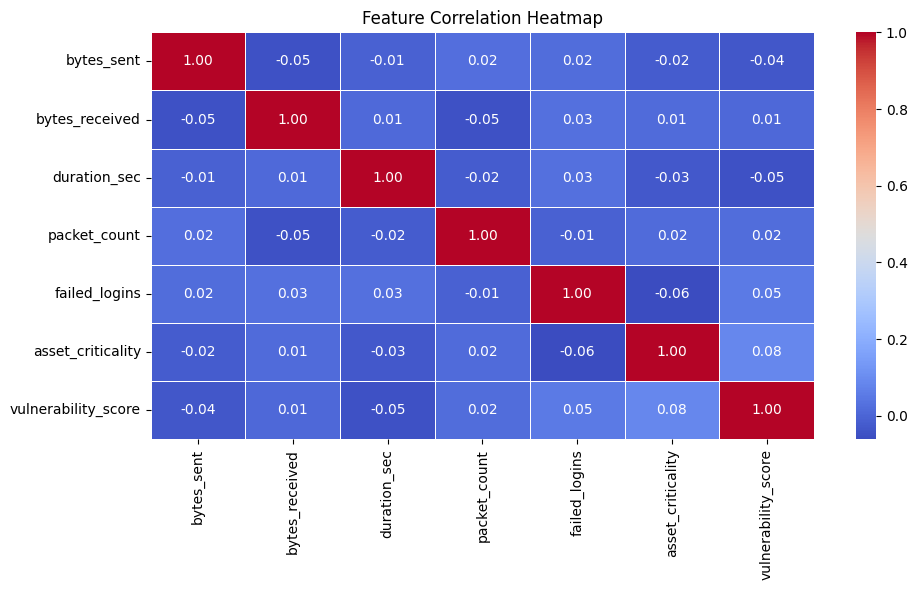

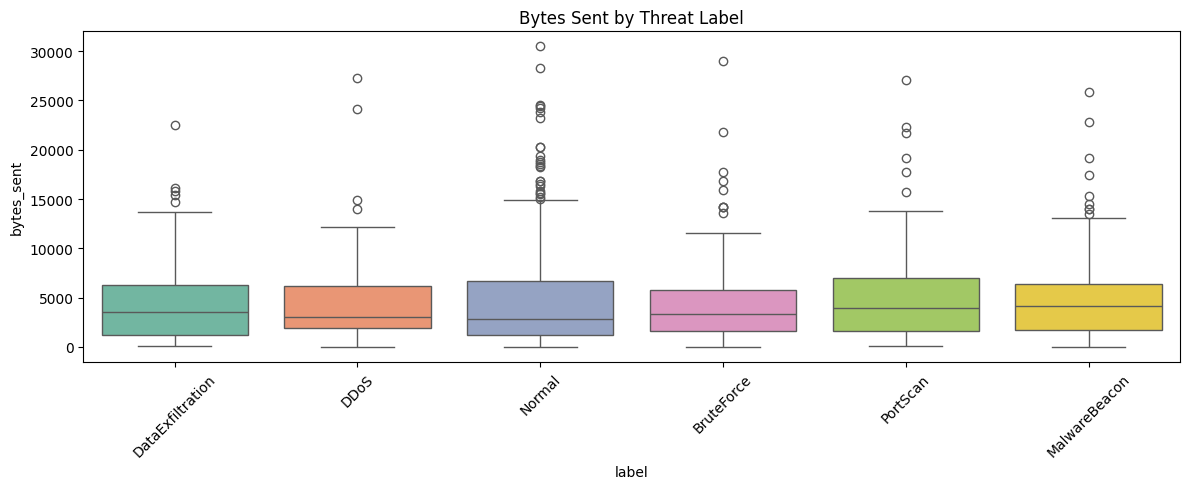

EDA complete.


In [2]:
# ============================================================
# TASK 2: Exploratory Data Analysis (EDA)
# ============================================================

print("=" * 60)
print("TASK 2: Exploratory Data Analysis")
print("=" * 60)

# 2a. Basic info
print("\n--- Dataset Info ---")
print(df.dtypes)
print("\n--- Null Values ---")
print(df.isnull().sum())
print("\n--- Summary Statistics ---")
print(df[['bytes_sent','bytes_received','duration_sec',
          'packet_count','failed_logins',
          'asset_criticality','vulnerability_score']].describe().round(2))

# 2b. Label distribution
print("\n--- Threat Label Distribution ---")
print(df['label'].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Label bar chart
df['label'].value_counts().plot(kind='bar', ax=axes[0],
                                color='steelblue', edgecolor='black')
axes[0].set_title('Threat Label Distribution')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Protocol distribution
df['protocol'].value_counts().plot(kind='pie', ax=axes[1],
                                   autopct='%1.1f%%', startangle=90)
axes[1].set_title('Protocol Distribution')
axes[1].set_ylabel('')

# Bytes sent distribution
axes[2].hist(df['bytes_sent'], bins=40, color='coral', edgecolor='black')
axes[2].set_title('Bytes Sent Distribution')
axes[2].set_xlabel('Bytes Sent')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# 2c. Correlation heatmap
plt.figure(figsize=(10, 6))
numeric_cols = ['bytes_sent','bytes_received','duration_sec',
                'packet_count','failed_logins',
                'asset_criticality','vulnerability_score']
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# 2d. Boxplot: bytes_sent by label
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='label', y='bytes_sent', palette='Set2')
plt.title('Bytes Sent by Threat Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("EDA complete.")

TASK 3: Anomaly Detection – Isolation Forest

--- Anomaly Detection Summary ---
anomaly_label
Normal     900
Anomaly    100
Name: count, dtype: int64

Anomaly Rate: 10.0%


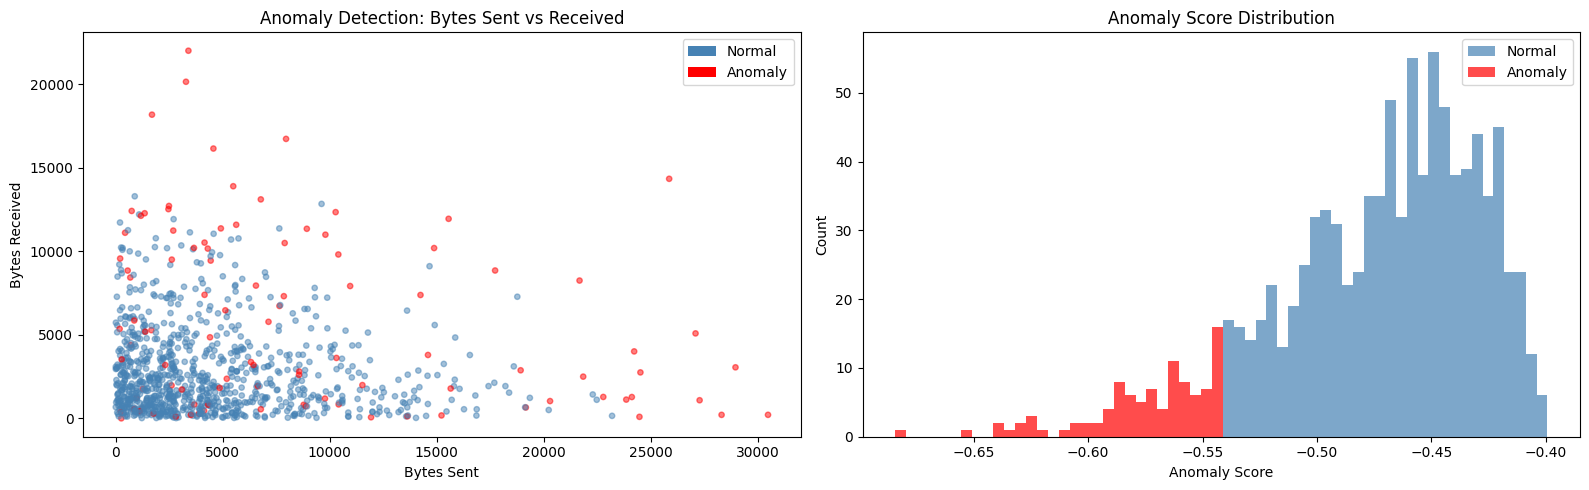

Anomaly detection complete.


In [3]:
# ============================================================
# TASK 3: Anomaly Detection using Isolation Forest
# ============================================================

print("=" * 60)
print("TASK 3: Anomaly Detection – Isolation Forest")
print("=" * 60)

# Feature set for anomaly detection
features_ad = ['bytes_sent', 'bytes_received', 'duration_sec',
               'packet_count', 'failed_logins',
               'asset_criticality', 'vulnerability_score']

X_ad = df[features_ad].copy()

# Scale features
scaler_ad = StandardScaler()
X_ad_scaled = scaler_ad.fit_transform(X_ad)

# Train Isolation Forest
iso_forest = IsolationForest(n_estimators=100, contamination=0.1,
                              random_state=42)
df['anomaly_score']  = iso_forest.fit(X_ad_scaled).score_samples(X_ad_scaled)
df['is_anomaly']     = iso_forest.predict(X_ad_scaled)  # -1 = anomaly, 1 = normal
df['anomaly_label']  = df['is_anomaly'].map({1: 'Normal', -1: 'Anomaly'})

print("\n--- Anomaly Detection Summary ---")
print(df['anomaly_label'].value_counts())
print(f"\nAnomaly Rate: {(df['is_anomaly'] == -1).mean()*100:.1f}%")

# Visualise anomalies
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter: bytes_sent vs bytes_received coloured by anomaly
colors = df['anomaly_label'].map({'Normal': 'steelblue', 'Anomaly': 'red'})
axes[0].scatter(df['bytes_sent'], df['bytes_received'],
                c=colors, alpha=0.5, s=15)
axes[0].set_title('Anomaly Detection: Bytes Sent vs Received')
axes[0].set_xlabel('Bytes Sent')
axes[0].set_ylabel('Bytes Received')
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor='steelblue', label='Normal'),
                Patch(facecolor='red',       label='Anomaly')]
axes[0].legend(handles=legend_elems)

# Anomaly score distribution
axes[1].hist(df[df['anomaly_label']=='Normal']['anomaly_score'],
             bins=30, alpha=0.7, color='steelblue', label='Normal')
axes[1].hist(df[df['anomaly_label']=='Anomaly']['anomaly_score'],
             bins=30, alpha=0.7, color='red',       label='Anomaly')
axes[1].set_title('Anomaly Score Distribution')
axes[1].set_xlabel('Anomaly Score')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Anomaly detection complete.")

TASK 4: Threat Classification – Random Forest
Train size: 800  |  Test size: 200

--- Classification Report ---
                  precision    recall  f1-score   support

      BruteForce       0.00      0.00      0.00        18
            DDoS       0.00      0.00      0.00        24
DataExfiltration       0.50      0.05      0.10        19
   MalwareBeacon       1.00      0.05      0.09        21
          Normal       0.49      0.99      0.66        98
        PortScan       0.00      0.00      0.00        20

        accuracy                           0.49       200
       macro avg       0.33      0.18      0.14       200
    weighted avg       0.40      0.49      0.34       200



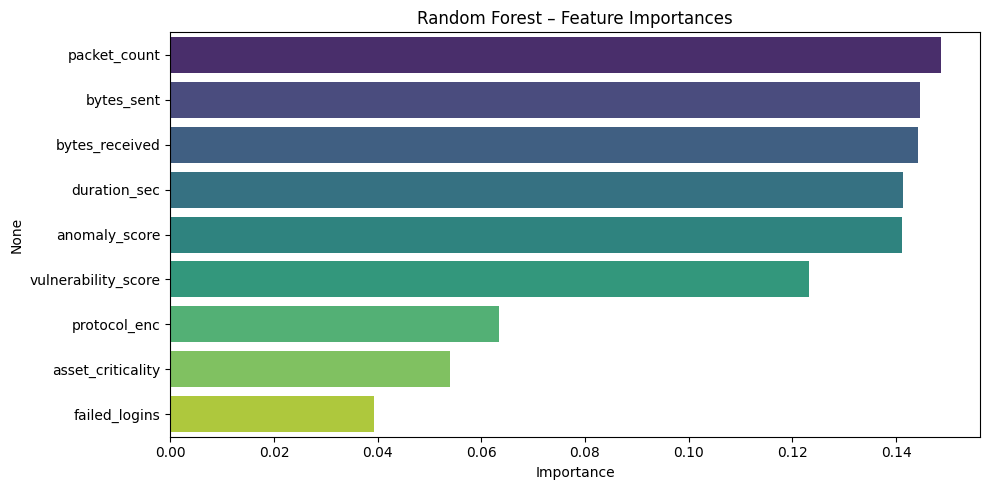

Threat classification complete.


In [4]:
# ============================================================
# TASK 4: Threat Classification using Random Forest
# ============================================================

print("=" * 60)
print("TASK 4: Threat Classification – Random Forest")
print("=" * 60)

# Encode protocol (categorical)
le_protocol = LabelEncoder()
df['protocol_enc'] = le_protocol.fit_transform(df['protocol'])

# Feature set for classification
features_clf = ['bytes_sent', 'bytes_received', 'duration_sec',
                'packet_count', 'failed_logins',
                'asset_criticality', 'vulnerability_score',
                'protocol_enc', 'anomaly_score']

X = df[features_clf]
y = df['label']

# Encode target
le_label = LabelEncoder()
y_enc = le_label.fit_transform(y)

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")

# Scale features
scaler_clf = StandardScaler()
X_train_sc = scaler_clf.fit_transform(X_train)
X_test_sc  = scaler_clf.transform(X_test)

# Train Random Forest
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=10,
                                 random_state=42, n_jobs=-1)
rf_clf.fit(X_train_sc, y_train)
y_pred = rf_clf.predict(X_test_sc)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred,
      target_names=le_label.classes_))

# Feature importance
importances = pd.Series(rf_clf.feature_importances_,
                        index=features_clf).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Random Forest – Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("Threat classification complete.")

TASK 5: Composite Risk Scoring

--- Risk Score Summary ---
count    1000.0000
mean        0.4661
std         0.1562
min         0.1360
25%         0.3481
50%         0.4595
75%         0.5801
max         0.8803
Name: risk_score, dtype: float64

--- Risk Tier Distribution ---
risk_tier
Medium      441
High        267
Low         253
Critical     39
Name: count, dtype: int64

--- Top 10 Highest Risk Events ---
 event_id            label  asset_criticality  vulnerability_score  risk_score risk_tier
      481 DataExfiltration                  5                  9.6      0.8803  Critical
       94    MalwareBeacon                  5                  9.8      0.8406  Critical
      168    MalwareBeacon                  5                  9.6      0.8351  Critical
      100    MalwareBeacon                  5                  9.4      0.8240  Critical
      662             DDoS                  5                  8.9      0.8220  Critical
      469    MalwareBeacon                  5         

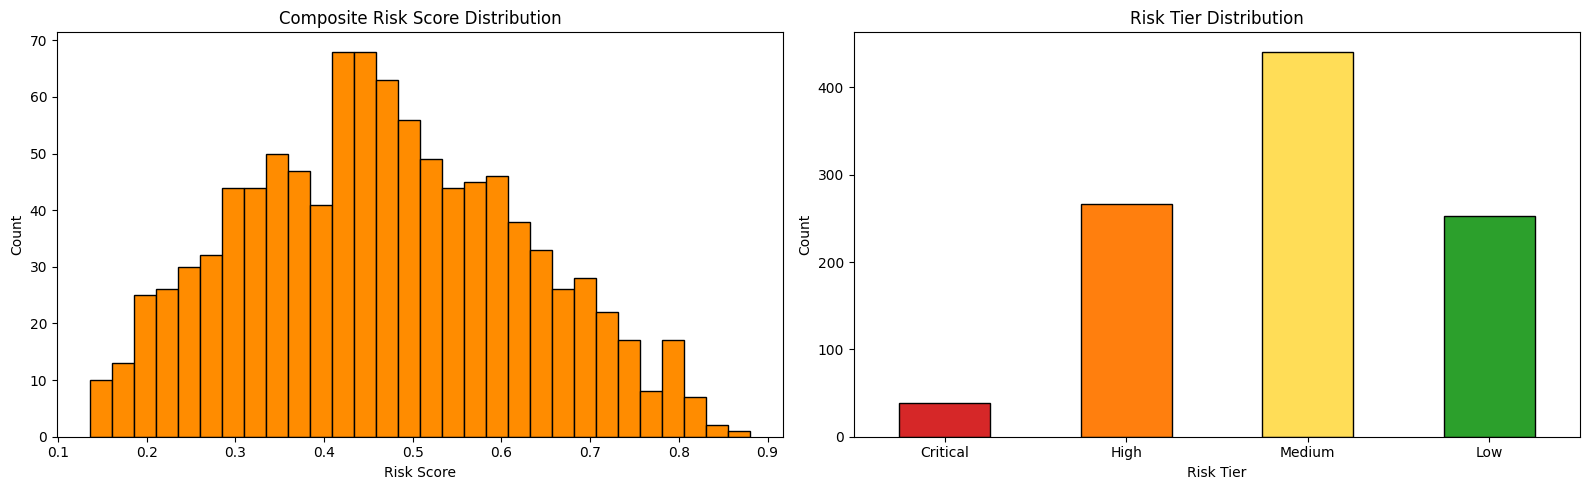

Risk scoring complete.


In [5]:
# ============================================================
# TASK 5: Composite Risk Scoring
# ============================================================

print("=" * 60)
print("TASK 5: Composite Risk Scoring")
print("=" * 60)

# Map threat label to severity weight
threat_severity = {
    'BruteForce'      : 0.7,
    'DataExfiltration': 0.9,
    'MalwareBeacon'   : 0.8,
    'PortScan'        : 0.5,
    'DDoS'            : 0.75,
    'Normal'          : 0.1,
}
df['threat_severity'] = df['label'].map(threat_severity)

# Normalise anomaly score to [0, 1]  (original range is negative)
df['anomaly_norm'] = 1 - (
    (df['anomaly_score'] - df['anomaly_score'].min()) /
    (df['anomaly_score'].max() - df['anomaly_score'].min())
)

# Composite Risk Score formula:
# risk = 0.35*threat_severity + 0.25*(asset_criticality/5)
#      + 0.25*(vulnerability_score/10) + 0.15*anomaly_norm
df['risk_score'] = (
    0.35 * df['threat_severity'] +
    0.25 * (df['asset_criticality'] / 5) +
    0.25 * (df['vulnerability_score'] / 10) +
    0.15 * df['anomaly_norm']
).round(4)

# Risk tier classification
def risk_tier(score):
    if score >= 0.75: return 'Critical'
    elif score >= 0.55: return 'High'
    elif score >= 0.35: return 'Medium'
    else: return 'Low'

df['risk_tier'] = df['risk_score'].apply(risk_tier)

print("\n--- Risk Score Summary ---")
print(df['risk_score'].describe().round(4))
print("\n--- Risk Tier Distribution ---")
print(df['risk_tier'].value_counts())

# Show top 10 highest-risk events
print("\n--- Top 10 Highest Risk Events ---")
print(df[['event_id','label','asset_criticality',
          'vulnerability_score','risk_score','risk_tier']]
      .sort_values('risk_score', ascending=False)
      .head(10).to_string(index=False))

# Visualise risk distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df['risk_score'], bins=30, color='darkorange', edgecolor='black')
axes[0].set_title('Composite Risk Score Distribution')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('Count')

tier_order = ['Critical', 'High', 'Medium', 'Low']
tier_counts = df['risk_tier'].value_counts().reindex(tier_order)
colors_tier = ['#d62728', '#ff7f0e', '#ffdd57', '#2ca02c']
tier_counts.plot(kind='bar', ax=axes[1], color=colors_tier, edgecolor='black')
axes[1].set_title('Risk Tier Distribution')
axes[1].set_xlabel('Risk Tier')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("Risk scoring complete.")

TASK 6: Model Evaluation

--- Weighted Metrics (Random Forest) ---
              Metric  Score
            Accuracy 0.4950
Precision (weighted) 0.3950
   Recall (weighted) 0.4950
 F1-Score (weighted) 0.3419


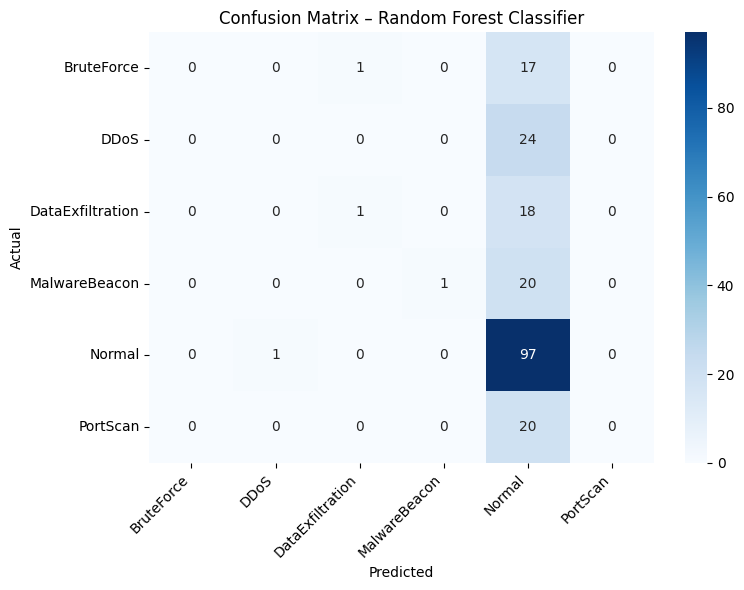

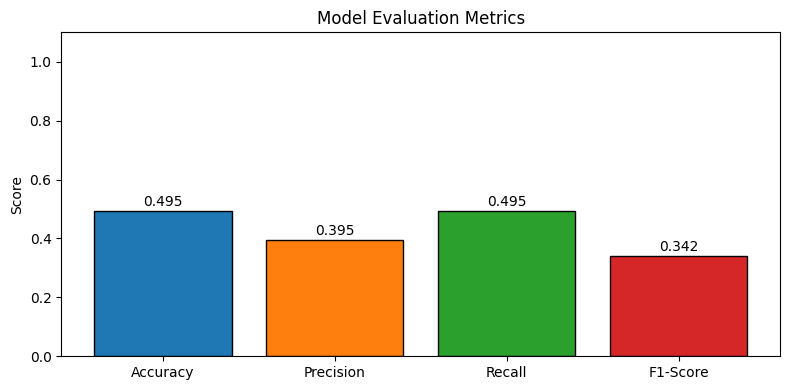


--- Risk Score Stats by Tier ---
           Events  Avg Score     Min     Max
risk_tier                                   
Critical       39     0.7901  0.7528  0.8803
High          267     0.6325  0.5500  0.7496
Low           253     0.2689  0.1360  0.3487
Medium        441     0.4499  0.3507  0.5496

ALL TASKS COMPLETED SUCCESSFULLY


In [6]:
# ============================================================
# TASK 6: Model Evaluation
# ============================================================

print("=" * 60)
print("TASK 6: Model Evaluation")
print("=" * 60)

# --- 6a. Classification metrics ---
acc       = accuracy_score(y_test, y_pred)
prec_wt   = precision_score(y_test, y_pred, average='weighted')
rec_wt    = recall_score(y_test, y_pred, average='weighted')
f1_wt     = f1_score(y_test, y_pred, average='weighted')

print("\n--- Weighted Metrics (Random Forest) ---")
metrics_df = pd.DataFrame({
    'Metric' : ['Accuracy', 'Precision (weighted)',
                'Recall (weighted)', 'F1-Score (weighted)'],
    'Score'  : [acc, prec_wt, rec_wt, f1_wt]
})
metrics_df['Score'] = metrics_df['Score'].round(4)
print(metrics_df.to_string(index=False))

# --- 6b. Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_label.classes_,
            yticklabels=le_label.classes_)
plt.title('Confusion Matrix – Random Forest Classifier')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 6c. Metrics bar chart ---
plt.figure(figsize=(8, 4))
bars = plt.bar(['Accuracy', 'Precision', 'Recall', 'F1-Score'],
               [acc, prec_wt, rec_wt, f1_wt],
               color=['#1f77b4','#ff7f0e','#2ca02c','#d62728'],
               edgecolor='black')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
plt.ylim(0, 1.1)
plt.title('Model Evaluation Metrics')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

# --- 6d. Risk score verification by tier ---
print("\n--- Risk Score Stats by Tier ---")
print(df.groupby('risk_tier')['risk_score']
        .agg(['count','mean','min','max'])
        .round(4)
        .rename(columns={'count':'Events','mean':'Avg Score',
                         'min':'Min','max':'Max'}))

print("\n" + "=" * 60)
print("ALL TASKS COMPLETED SUCCESSFULLY")
print("=" * 60)